# Bootstrap Analysis for Self-Prioritization Effect in Mismatch Conditions (v2)

**Objective**: Compute self-prioritization effect (Self vs. Stranger) in mismatch conditions with bootstrap resampling.

**Key Features**:
1. Separate Shape and Label analysis
2. RT and ACC as dependent variables
3. Bootstrap with replacement (matching R code)
4. Strict and Loose filtering criteria

**Based on**: R code from "use example_12.14.R" (bootstrap 2.0)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Define paths
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap")
output_path.mkdir(exist_ok=True)

# Find all Clean.csv files
clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")

Found 72 Clean.csv files


In [3]:
# Load and merge all Clean.csv files
all_data = []

for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        df['Source'] = file_path.stem
        all_data.append(df)
        print(f"Loaded: {file_path.name} - {len(df)} rows")
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

# Merge all dataframes
merged_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal merged data: {len(merged_df)} rows")

Loaded: Amodeo_2024_CABN_Exp1_Clean.csv - 24120 rows
Loaded: Constable_2020_AP_Exp1_Clean.csv - 22080 rows
Loaded: Feldborg_2021_ERPH_Exp1_Clean.csv - 32640 rows
Loaded: Haciahmet_2023_Psy_Exp1_Clean.csv - 10560 rows
Loaded: Hobbs_2023_PM_Exp1_Clean.csv - 0 rows
Loaded: Hu_2020_CP_Exp1_Clean.csv - 25920 rows
Loaded: Hu_2023_Exp1_Clean.csv - 35070 rows
Loaded: Kolvoort_2020_HBM_Exp1_Clean.csv - 11051 rows
Loaded: Liang_2022_HBM_Exp1.1_Clean.csv - 25382 rows
Loaded: Liang_2022_HBM_Exp1.2_Clean.csv - 26082 rows
Loaded: Liang_2022_HBM_Exp1.3_Clean.csv - 26594 rows
Loaded: Liang_2022_HBM_Exp1_Clean.csv - 25382 rows
Loaded: Liu_2023_CP_Exp1_Clean.csv - 19136 rows
Loaded: Martinez-Perez_2024_CC_Exp2_Clean.csv - 7680 rows
Loaded: Mcivor_2020_EJN_Exp1_Clean.csv - 38880 rows
Loaded: Pan_2025_Exp1_Clean.csv - 28037 rows
Loaded: Perrykkad_2022_BMC_Exp1_Clean.csv - 120240 rows
Loaded: Smith_2024_Cortex_Exp1_Clean.csv - 17280 rows
Loaded: Sui_2014_Exp1_Clean.csv - 17280 rows
Loaded: Sui_2023_CC_Exp1

In [4]:
# Check columns
print("Columns:", list(merged_df.columns))
print(f"\nUnique Matching values: {merged_df['Matching'].unique()}")
print(f"Unique Shape_Standardized_Identity values: {merged_df['Shape_Standardized_Identity'].unique()}")
if 'Label_Standardized_Identity' in merged_df.columns:
    print(f"Unique Label_Standardized_Identity values: {merged_df['Label_Standardized_Identity'].unique()}")
else:
    print("WARNING: Label_Standardized_Identity not found")
    merged_df['Label_Standardized_Identity'] = merged_df['Shape_Standardized_Identity']

Columns: ['Subject', 'Block', 'Trial', 'Shape', 'Label', 'Matching', 'Label_Origin_Identity', 'Label_English_Identity', 'Label_Standardized_Identity', 'Shape_Origin_Identity', 'Shape_English_Identity', 'Shape_Standardized_Identity', 'Response', 'RT_ms', 'RT_sec', 'ACC', 'Source', 'StrangerShape', 'P1Shape', 'P2Shape', 'ShapeLoc', 'Phase', 'Group', 'Condition', 'Bin', 'Morality', 'Session', 'Face', 'Stim_Type', 'Stim', 'Valence', 'Domain', 'Colour', 'ShapeColour', 'textColour', 'Stimuli_Type', 'FaceIdentity', 'Stimulus', 'Strength', 'Race', 'Speaker', 'Accent', 'Voice', 'Mood', 'Arouse', 'Unnamed: 0', 'Identity', 'Symmetry', 'Face_Gender', 'Label1', 'Label2', 'Label3']

Unique Matching values: ['Matching' 'Nonmatching' nan 'Unknown']
Unique Shape_Standardized_Identity values: ['Stranger' 'Self' 'Close' nan 'Unknown' 'Celebrity' 'NonPerson'
 'Acquaintance']
Unique Label_Standardized_Identity values: ['Stranger' 'Self' 'Friend' nan 'Me' 'Close']


In [5]:
# Define helper functions
def cohens_d(group1, group2):
    """Calculate Cohen's d between two groups."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_sd == 0:
        return np.nan
    
    return (mean1 - mean2) / pooled_sd

print("Helper functions defined!")

Helper functions defined!


In [6]:
# Define data processing functions (matching R code logic)
def filter_valid_subjects(df, identity_column):
    """Filter subjects with Self, Stranger, and at least 3 identities."""
    valid_subjects = []
    
    for subject, subj_df in df.groupby('Subject'):
        identities = set(subj_df[identity_column].dropna().unique())
        has_self = 'Self' in identities
        has_stranger = 'Stranger' in identities
        identity_count = len(identities)
        
        if has_self and has_stranger and identity_count >= 3:
            valid_subjects.append(subject)
    
    return valid_subjects

def process_data_strict(df, analysis_type='Shape'):
    """Process data with STRICT filtering."""
    if analysis_type == 'Shape':
        identity_column = 'Shape_Standardized_Identity'
        secondary_column = 'Label_Standardized_Identity'
    else:
        identity_column = 'Label_Standardized_Identity'
        secondary_column = 'Shape_Standardized_Identity'
    
    valid_subjects = filter_valid_subjects(df, identity_column)
    df_filtered = df[df['Subject'].isin(valid_subjects)].copy()
    
    df_filtered['Primary'] = df_filtered[identity_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    df_filtered['Secondary'] = df_filtered[secondary_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    
    mask = (
        (df_filtered['Primary'] == 'Self') |
        ((df_filtered['Primary'] == 'Stranger') & (df_filtered['Secondary'] != 'Self')) |
        (df_filtered['Primary'] == 'Other')
    )
    
    return df_filtered[mask].copy()

def process_data_loose(df, analysis_type='Shape'):
    """Process data with LOOSE filtering."""
    if analysis_type == 'Shape':
        identity_column = 'Shape_Standardized_Identity'
    else:
        identity_column = 'Label_Standardized_Identity'
    
    df_filtered = df.copy()
    df_filtered['Primary'] = df_filtered[identity_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    
    return df_filtered[df_filtered['Primary'].isin(['Self', 'Stranger'])].copy()

print("Data processing functions defined!")

Data processing functions defined!


In [7]:
# Define Cohen's d calculation function
def calculate_cohens_d_per_subject(df, measure='RT', min_trials=2):
    """Calculate Cohen's d for each participant."""
    results = []
    
    for subject, subj_df in df.groupby('Subject'):
        self_data = subj_df[subj_df['Primary'] == 'Self']
        stranger_data = subj_df[subj_df['Primary'] == 'Stranger']
        
        if measure == 'RT':
            self_values = self_data[self_data['ACC'] == 1]['RT_ms'].dropna().values
            stranger_values = stranger_data[stranger_data['ACC'] == 1]['RT_ms'].dropna().values
        else:
            self_values = self_data['ACC'].dropna().values
            stranger_values = stranger_data['ACC'].dropna().values
        
        if len(self_values) < min_trials or len(stranger_values) < min_trials:
            continue
        
        if measure == 'RT':
            d = cohens_d(stranger_values, self_values)  # Stranger - Self
        else:
            d = cohens_d(self_values, stranger_values)  # Self - Stranger
        
        if not np.isnan(d):
            results.append({
                'Subject': subject,
                'Cohens_d': d,
                'n_self': len(self_values),
                'n_stranger': len(stranger_values)
            })
    
    return pd.DataFrame(results)

print("Cohen's d calculation function defined!")

Cohen's d calculation function defined!


In [8]:
# Define bootstrap function (matching R code)
def bootstrap_analysis(cohens_d_values, n_bootstrap=500, min_n=10, step=10):
    """Perform bootstrap resampling WITH REPLACEMENT."""
    max_n = len(cohens_d_values)
    if max_n < min_n:
        return pd.DataFrame()
    
    sample_sizes = list(range(min_n, max_n + 1, step))
    if max_n % step != 0 and max_n not in sample_sizes:
        sample_sizes.append(max_n)
    sample_sizes = sorted(set(sample_sizes))
    
    results = []
    
    for n in sample_sizes:
        if n > len(cohens_d_values):
            continue
        
        bootstrap_means = []
        for _ in range(n_bootstrap):
            sampled = np.random.choice(cohens_d_values, size=n, replace=True)
            bootstrap_means.append(np.mean(sampled))
        
        bootstrap_means = np.array(bootstrap_means)
        
        results.append({
            'SampleSize': n,
            'Mean_d': np.mean(bootstrap_means),
            'SE': np.std(bootstrap_means),
            'CI_lower': np.percentile(bootstrap_means, 2.5),
            'CI_upper': np.percentile(bootstrap_means, 97.5)
        })
    
    return pd.DataFrame(results)

print("Bootstrap function defined!")

Bootstrap function defined!


In [9]:
# Filter for Nonmatching trials
mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)} rows")
print(f"Unique participants: {mismatch_df['Subject'].nunique()}")

Mismatch trials: 853015 rows
Unique participants: 1676


In [10]:
# Run STRICT filtering analysis
print("=== STRICT FILTERING ===")

# RT Analysis
print("\nRT Analysis:")
rt_shape_strict = process_data_strict(mismatch_df, 'Shape')
rt_label_strict = process_data_strict(mismatch_df, 'Label')

rt_shape_cohens_strict = calculate_cohens_d_per_subject(rt_shape_strict, 'RT')
rt_label_cohens_strict = calculate_cohens_d_per_subject(rt_label_strict, 'RT')

print(f"  Shape: {len(rt_shape_cohens_strict)} participants")
print(f"  Label: {len(rt_label_cohens_strict)} participants")

# Bootstrap
rt_shape_boot_strict = bootstrap_analysis(rt_shape_cohens_strict['Cohens_d'].values, 500)
rt_shape_boot_strict['Identity'] = 'Shape'

rt_label_boot_strict = bootstrap_analysis(rt_label_cohens_strict['Cohens_d'].values, 500)
rt_label_boot_strict['Identity'] = 'Label'

rt_boot_strict = pd.concat([rt_shape_boot_strict, rt_label_boot_strict], ignore_index=True)

=== STRICT FILTERING ===

RT Analysis:
  Shape: 792 participants
  Label: 610 participants


In [11]:
# ACC Analysis (Strict)
print("\nACC Analysis:")
acc_shape_strict = process_data_strict(mismatch_df, 'Shape')
acc_label_strict = process_data_strict(mismatch_df, 'Label')

acc_shape_cohens_strict = calculate_cohens_d_per_subject(acc_shape_strict, 'ACC')
acc_label_cohens_strict = calculate_cohens_d_per_subject(acc_label_strict, 'ACC')

print(f"  Shape: {len(acc_shape_cohens_strict)} participants")
print(f"  Label: {len(acc_label_cohens_strict)} participants")

# Bootstrap
acc_shape_boot_strict = bootstrap_analysis(acc_shape_cohens_strict['Cohens_d'].values, 500)
acc_shape_boot_strict['Identity'] = 'Shape'

acc_label_boot_strict = bootstrap_analysis(acc_label_cohens_strict['Cohens_d'].values, 500)
acc_label_boot_strict['Identity'] = 'Label'

acc_boot_strict = pd.concat([acc_shape_boot_strict, acc_label_boot_strict], ignore_index=True)


ACC Analysis:
  Shape: 782 participants
  Label: 590 participants


In [12]:
# Run LOOSE filtering analysis
print("=== LOOSE FILTERING ===")

# RT Analysis
print("\nRT Analysis:")
rt_shape_loose = process_data_loose(mismatch_df, 'Shape')
rt_label_loose = process_data_loose(mismatch_df, 'Label')

rt_shape_cohens_loose = calculate_cohens_d_per_subject(rt_shape_loose, 'RT')
rt_label_cohens_loose = calculate_cohens_d_per_subject(rt_label_loose, 'RT')

print(f"  Shape: {len(rt_shape_cohens_loose)} participants")
print(f"  Label: {len(rt_label_cohens_loose)} participants")

# Bootstrap
rt_shape_boot_loose = bootstrap_analysis(rt_shape_cohens_loose['Cohens_d'].values, 500)
rt_shape_boot_loose['Identity'] = 'Shape'

rt_label_boot_loose = bootstrap_analysis(rt_label_cohens_loose['Cohens_d'].values, 500)
rt_label_boot_loose['Identity'] = 'Label'

rt_boot_loose = pd.concat([rt_shape_boot_loose, rt_label_boot_loose], ignore_index=True)

=== LOOSE FILTERING ===

RT Analysis:
  Shape: 964 participants
  Label: 813 participants


In [13]:
# ACC Analysis (Loose)
print("\nACC Analysis:")
acc_shape_loose = process_data_loose(mismatch_df, 'Shape')
acc_label_loose = process_data_loose(mismatch_df, 'Label')

acc_shape_cohens_loose = calculate_cohens_d_per_subject(acc_shape_loose, 'ACC')
acc_label_cohens_loose = calculate_cohens_d_per_subject(acc_label_loose, 'ACC')

print(f"  Shape: {len(acc_shape_cohens_loose)} participants")
print(f"  Label: {len(acc_label_cohens_loose)} participants")

# Bootstrap
acc_shape_boot_loose = bootstrap_analysis(acc_shape_cohens_loose['Cohens_d'].values, 500)
acc_shape_boot_loose['Identity'] = 'Shape'

acc_label_boot_loose = bootstrap_analysis(acc_label_cohens_loose['Cohens_d'].values, 500)
acc_label_boot_loose['Identity'] = 'Label'

acc_boot_loose = pd.concat([acc_shape_boot_loose, acc_label_boot_loose], ignore_index=True)


ACC Analysis:
  Shape: 954 participants
  Label: 800 participants


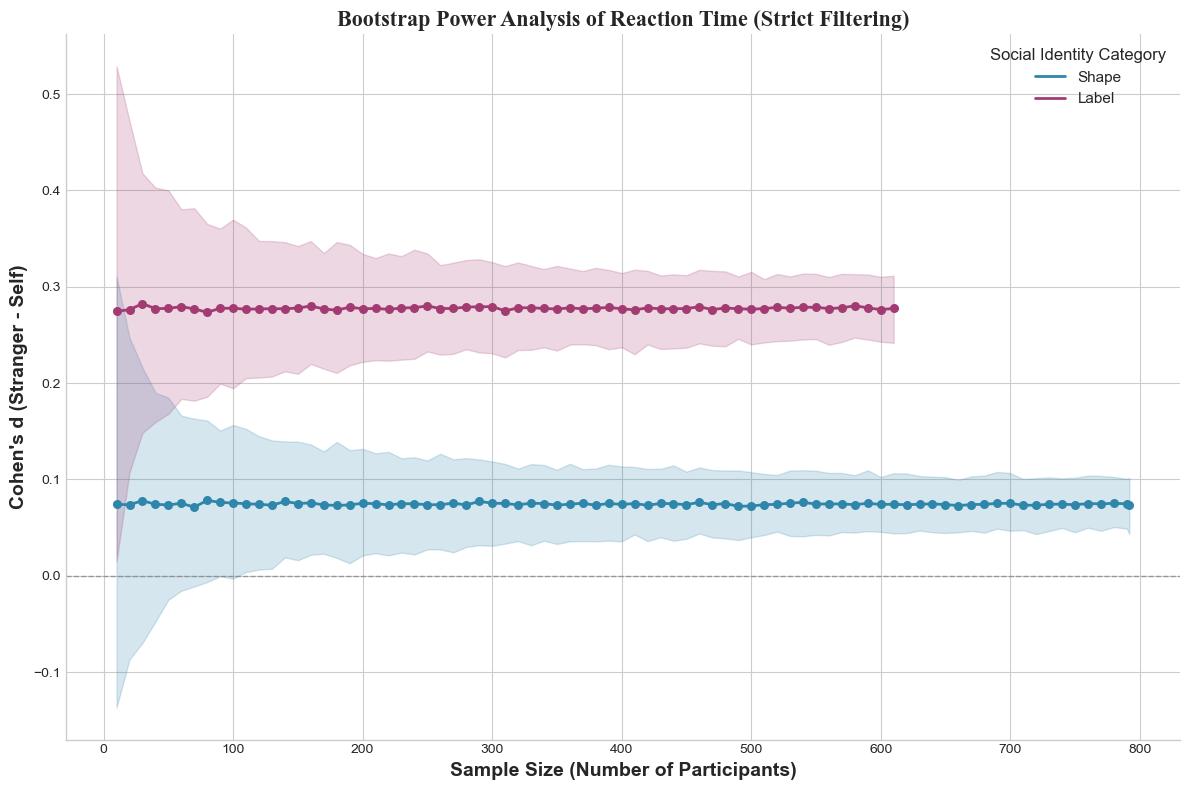

Saved: bootstrap_rt_strict.png


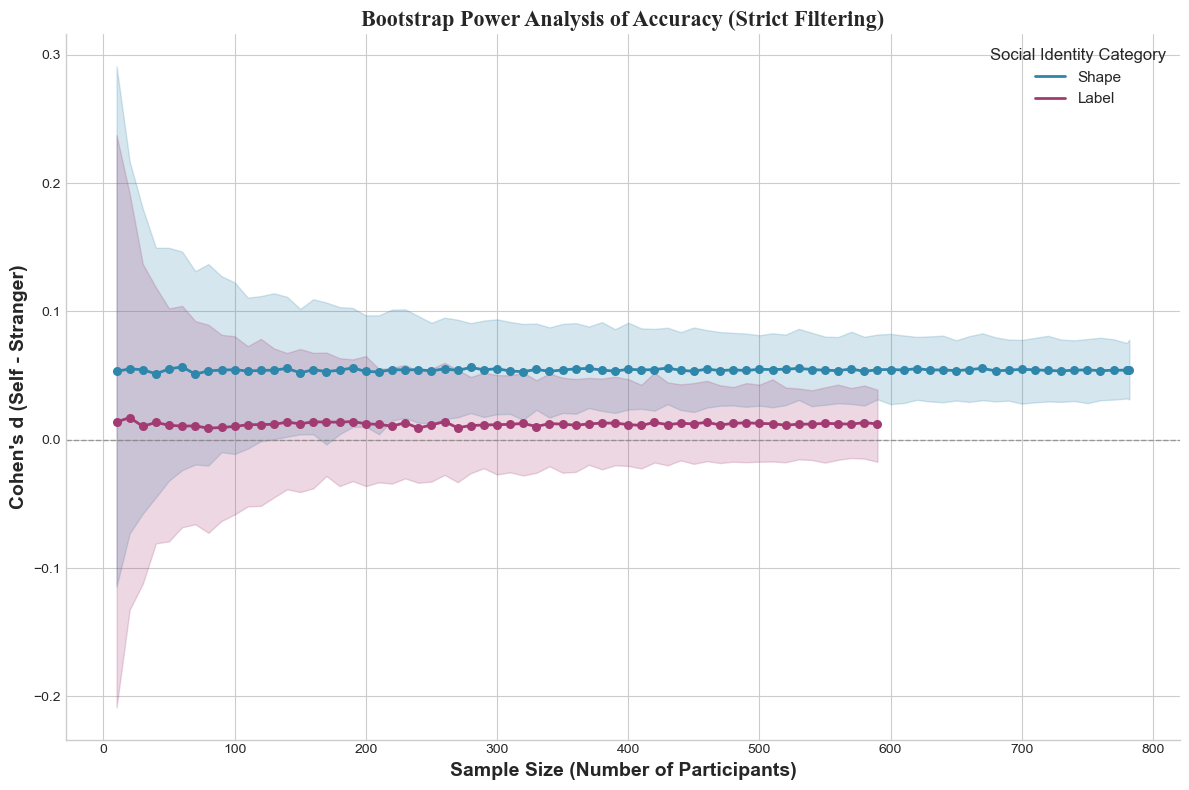

Saved: bootstrap_acc_strict.png


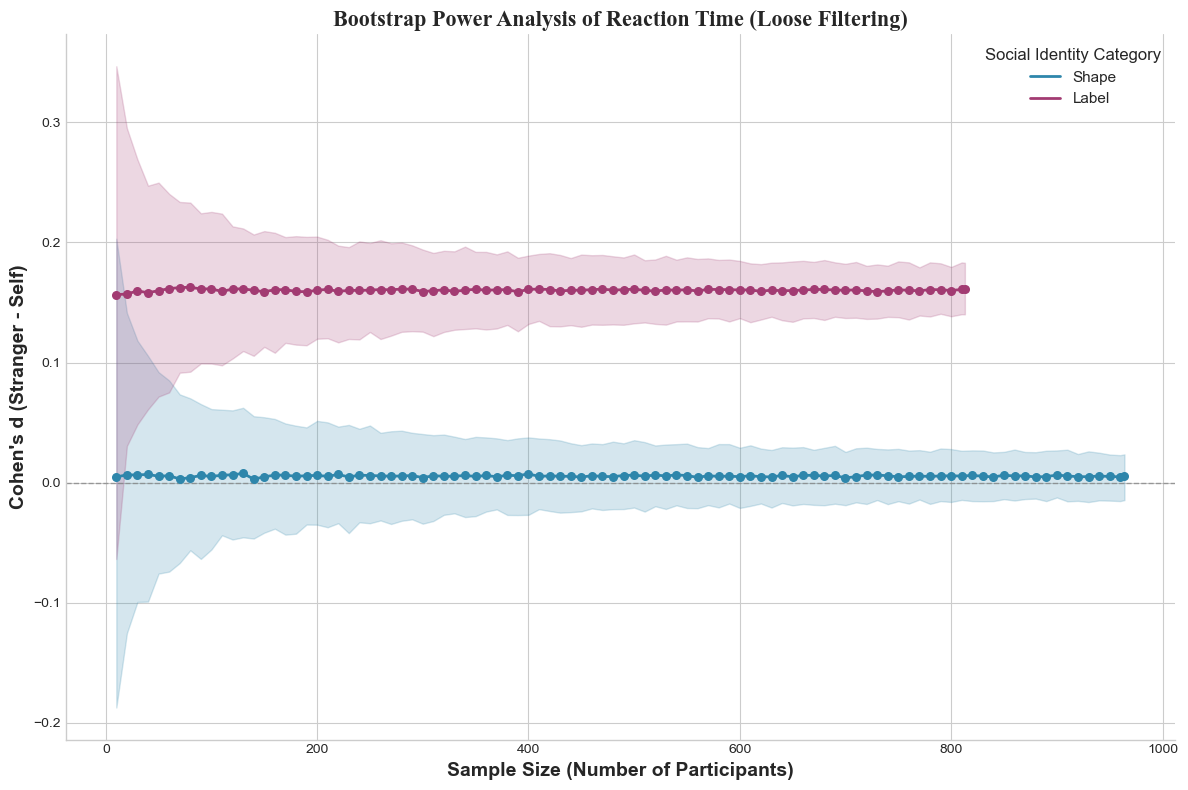

Saved: bootstrap_rt_loose.png


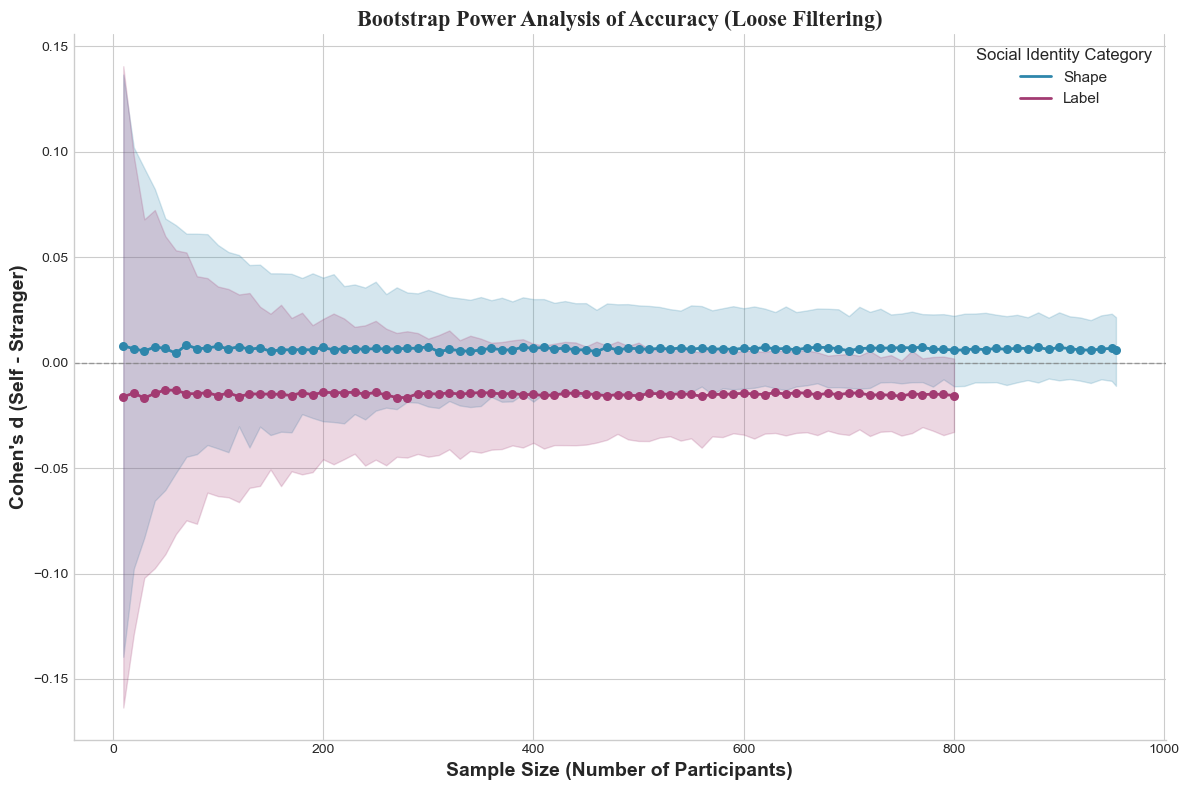

Saved: bootstrap_acc_loose.png


In [14]:
# Create individual figures
identity_colors = {'Shape': '#2E86AB', 'Label': '#A23B72'}

def create_plot(data, title, y_label, filename):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for identity in ['Shape', 'Label']:
        subset = data[data['Identity'] == identity]
        if subset.empty:
            continue
        
        color = identity_colors[identity]
        ax.plot(subset['SampleSize'], subset['Mean_d'], 
               color=color, linewidth=2, label=identity)
        ax.fill_between(subset['SampleSize'], 
                       subset['CI_lower'], 
                       subset['CI_upper'], 
                       color=color, alpha=0.2)
        ax.scatter(subset['SampleSize'], subset['Mean_d'], 
                  color=color, s=30, zorder=5)
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Sample Size (Number of Participants)', fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', family='Times New Roman')
    ax.legend(title='Social Identity Category', title_fontsize=12, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# Generate all 4 figures
create_plot(rt_boot_strict, 
           'Bootstrap Power Analysis of Reaction Time (Strict Filtering)',
           "Cohen's d (Stranger - Self)",
           'bootstrap_rt_strict.png')

create_plot(acc_boot_strict,
           'Bootstrap Power Analysis of Accuracy (Strict Filtering)',
           "Cohen's d (Self - Stranger)",
           'bootstrap_acc_strict.png')

create_plot(rt_boot_loose,
           'Bootstrap Power Analysis of Reaction Time (Loose Filtering)',
           "Cohen's d (Stranger - Self)",
           'bootstrap_rt_loose.png')

create_plot(acc_boot_loose,
           'Bootstrap Power Analysis of Accuracy (Loose Filtering)',
           "Cohen's d (Self - Stranger)",
           'bootstrap_acc_loose.png')

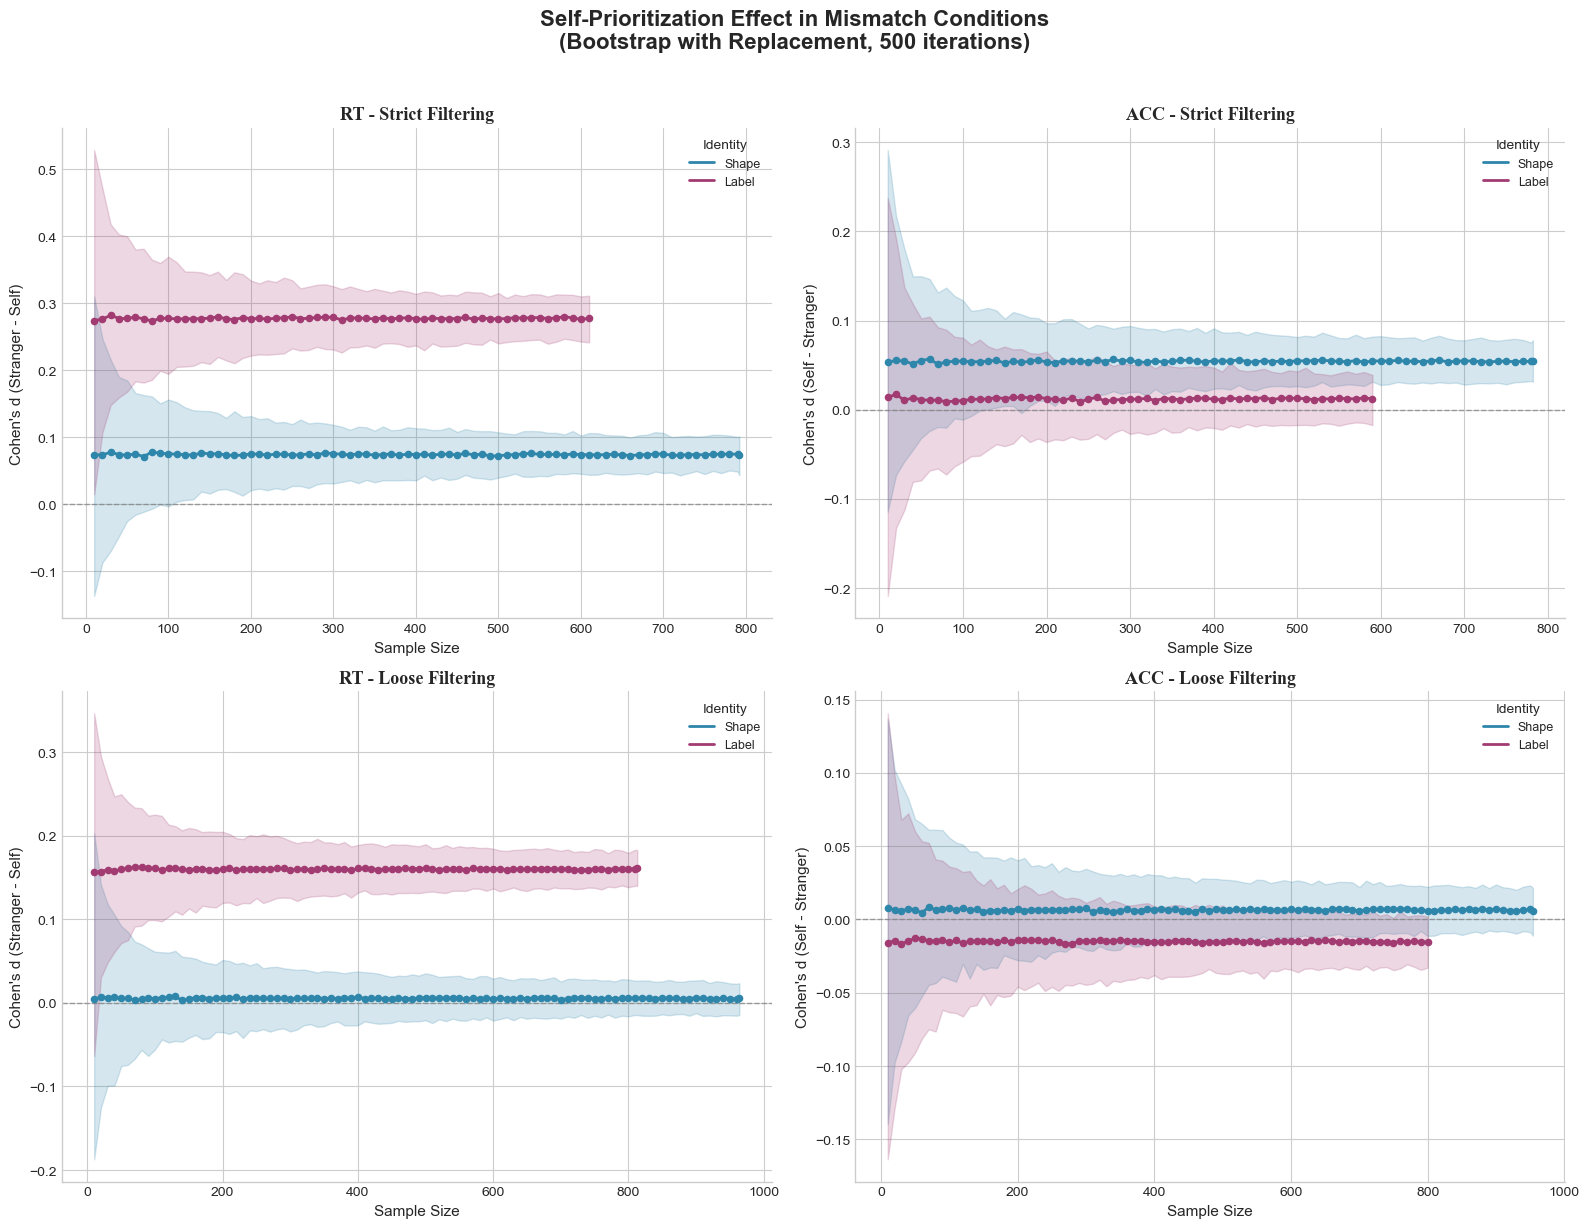

Saved: combined_figures_300dpi.png


In [15]:
# Create combined 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_configs = [
    (axes[0, 0], rt_boot_strict, "Cohen's d (Stranger - Self)", 'RT - Strict Filtering'),
    (axes[0, 1], acc_boot_strict, "Cohen's d (Self - Stranger)", 'ACC - Strict Filtering'),
    (axes[1, 0], rt_boot_loose, "Cohen's d (Stranger - Self)", 'RT - Loose Filtering'),
    (axes[1, 1], acc_boot_loose, "Cohen's d (Self - Stranger)", 'ACC - Loose Filtering'),
]

for ax, data, y_label, title in plot_configs:
    for identity in ['Shape', 'Label']:
        subset = data[data['Identity'] == identity]
        if subset.empty:
            continue
        
        color = identity_colors[identity]
        ax.plot(subset['SampleSize'], subset['Mean_d'], 
               color=color, linewidth=2, label=identity)
        ax.fill_between(subset['SampleSize'], 
                       subset['CI_lower'], 
                       subset['CI_upper'], 
                       color=color, alpha=0.2)
        ax.scatter(subset['SampleSize'], subset['Mean_d'], 
                  color=color, s=20, zorder=5)
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Sample Size', fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', family='Times New Roman')
    ax.legend(title='Identity', fontsize=9, title_fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Self-Prioritization Effect in Mismatch Conditions\n(Bootstrap with Replacement, 500 iterations)', 
            fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(output_path / 'combined_figures_300dpi.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: combined_figures_300dpi.png")

In [16]:
# Save all results
rt_boot_strict.to_csv(output_path / 'bootstrap_rt_strict.csv', index=False)
acc_boot_strict.to_csv(output_path / 'bootstrap_acc_strict.csv', index=False)
rt_boot_loose.to_csv(output_path / 'bootstrap_rt_loose.csv', index=False)
acc_boot_loose.to_csv(output_path / 'bootstrap_acc_loose.csv', index=False)

# Save Cohen's d by participant
all_cohens_d = []
for df, filtering, measure, identity in [
    (rt_shape_cohens_strict, 'Strict', 'RT', 'Shape'),
    (rt_label_cohens_strict, 'Strict', 'RT', 'Label'),
    (acc_shape_cohens_strict, 'Strict', 'ACC', 'Shape'),
    (acc_label_cohens_strict, 'Strict', 'ACC', 'Label'),
    (rt_shape_cohens_loose, 'Loose', 'RT', 'Shape'),
    (rt_label_cohens_loose, 'Loose', 'RT', 'Label'),
    (acc_shape_cohens_loose, 'Loose', 'ACC', 'Shape'),
    (acc_label_cohens_loose, 'Loose', 'ACC', 'Label'),
]:
    if not df.empty:
        df_copy = df.copy()
        df_copy['Filtering'] = filtering
        df_copy['Measure'] = measure
        df_copy['Identity'] = identity
        all_cohens_d.append(df_copy)

if all_cohens_d:
    pd.concat(all_cohens_d, ignore_index=True).to_csv(
        output_path / 'cohens_d_by_participant.csv', index=False
    )

print("All results saved!")

All results saved!


In [17]:
# Print summary
print("=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

for filtering, rt_boot, acc_boot in [
    ('Strict', rt_boot_strict, acc_boot_strict),
    ('Loose', rt_boot_loose, acc_boot_loose)
]:
    print(f"\n{filtering} Filtering:")
    
    for measure, boot_data in [('RT', rt_boot), ('ACC', acc_boot)]:
        if not boot_data.empty:
            print(f"  {measure}:")
            for identity in ['Shape', 'Label']:
                subset = boot_data[boot_data['Identity'] == identity]
                if not subset.empty:
                    final = subset.iloc[-1]
                    sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                    print(f"    {identity}: Mean d = {final['Mean_d']:.3f}, "
                          f"95% CI [{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], "
                          f"Significant: {sig}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)

ANALYSIS SUMMARY

Strict Filtering:
  RT:
    Shape: Mean d = 0.074, 95% CI [0.043, 0.102], Significant: Yes
    Label: Mean d = 0.278, 95% CI [0.242, 0.311], Significant: Yes
  ACC:
    Shape: Mean d = 0.055, 95% CI [0.031, 0.078], Significant: Yes
    Label: Mean d = 0.012, 95% CI [-0.017, 0.039], Significant: No

Loose Filtering:
  RT:
    Shape: Mean d = 0.006, 95% CI [-0.014, 0.024], Significant: No
    Label: Mean d = 0.161, 95% CI [0.140, 0.183], Significant: Yes
  ACC:
    Shape: Mean d = 0.006, 95% CI [-0.011, 0.022], Significant: No
    Label: Mean d = -0.016, 95% CI [-0.033, 0.002], Significant: No

ANALYSIS COMPLETE!


## Methodology Notes

### Data Filtering

**Strict Filtering**:
- Requires both Shape and Label information
- Requires at least 3 different identities per participant
- Excludes trials where Primary=Stranger and Secondary=Self
- This controls for self-relevance confounds

**Loose Filtering**:
- Only requires Primary to be Self or Stranger
- No filtering based on Secondary

### Cohen's d Calculation

- **RT**: Cohen's d = (Mean_Stranger - Mean_Self) / Pooled_SD
- **ACC**: Cohen's d = (Mean_Self - Mean_Stranger) / Pooled_SD

### Bootstrap Resampling

- 500 iterations per sample size
- Sample sizes: 10, 20, 30, ..., n_participants
- **With replacement** (matching R code)
- Calculates mean Cohen's d and 95% confidence interval

### References

1. Sui, J., He, X., & Humphreys, G. W. (2012). Perceptual effects of self-relevance. *Journal of Experimental Psychology: Human Perception and Performance*, 38(5), 1105-1117.

2. Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.

3. Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall.